In [1]:
import pandas as pd

In [2]:
#orders.csv
url="https://drive.google.com/file/d/139r6wp1mtCUvtix85PzlqYo5042uVOtC/view?usp=sharing"
path = "https://drive.google.com/uc?export=download&id="+url.split("/")[-2]
orders = pd.read_csv(path)

In [3]:
#orderlines.csv
url="https://drive.google.com/file/d/1wRLmdfNVgKRIuPUOj7R3JZSc3gUG5LzU/view?usp=sharing"
path = "https://drive.google.com/uc?export=download&id="+url.split("/")[-2]
orderlines= pd.read_csv(path)

In [4]:
#products.csv
url ="https://drive.google.com/file/d/1q9Qwq4v0LJVCSQ9WnhUxhHFC4yqbHdCT/view?usp=sharing"
path = "https://drive.google.com/uc?export=download&id="+url.split("/")[-2]
products = pd.read_csv(path)

In [5]:
#brands.csv
url="https://drive.google.com/file/d/1XCy7T4m8FqIMAdpY8iwJTY8tosA5w2Th/view?usp=sharing"
path = "https://drive.google.com/uc?export=download&id="+url.split("/")[-2]
brands = pd.read_csv(path)

In [6]:
orders['created_date']=pd.to_datetime(orders['created_date'])
orderlines['date']=pd.to_datetime(orderlines['date'])
orderlines['unit_price']=pd.to_numeric(orderlines['unit_price'])
products["price"] = pd.to_numeric(products["price"], errors="coerce")

In [7]:
orders_df=orders.copy()
orderlines_df=orderlines.copy()
products_df=products.copy()
brands_df=brands.copy()

In [8]:
pd.set_option("display.float_format", lambda x : "%.2f" % x)
pd.set_option("display.max_rows",1000)

In [9]:
products_df["category"] = ""

In [10]:
products_df["category"].value_counts()

,count
category,
,9992


In [11]:
#apple watch
products_df.loc[(products_df["type"] == "24885185") | (products_df["type"] == "24895185"),'category']='Wearable'


In [12]:
# smart watch
l=['WIT0021','WIT0022','PEB0001-A','PEB0009-A','PEB0015','SPH0017','SPH0016','FIT0028',
 'FIT0029','FIT0024','FIT0025','FIT0027','JAW0043','JAW0044','JAW0045']
products_df.loc[(products_df["sku"].isin(l)),'category']='Wearable'

In [13]:
# wifi router/switch
products_df.loc[products_df["type"] == "1334",'category']= 'Networking'

In [14]:
# Protective accesories
products_df.loc[
    (products_df["category"].isna() | (products_df["category"] == "")) &
     (products_df["name"].str.contains(r"case|cover|sleeve|pouch|protector|keyboard case|Leather case|covers|cases|backpack", case=False)),'category']='Protective accesories'



In [15]:
# Protective accesories
s_list=['APP2543','APP2544','APP2547','APP2545','APP2546','APP2540-A','APP1702']
products_df.loc[(products_df["sku"].isin(s_list)),'category']='Protective accesories'

In [16]:
#cases
products_df.loc[(products_df["type"] == '12635403')& (products_df["category"] == ""),'category']='Protective accesories'

In [17]:
# speaker
products_df.loc[
    (products_df["category"].isna() | (products_df["category"] == "")) &
    ((products_df["name"].str.contains("wireless speaker|bluetooth speaker|portable speaker|waterproof speaker|compact speakers|portable bluetooth speaker|speakers", case=False))|
    (products_df["desc"].str.contains("wireless speaker|bluetooth speaker|portable speaker|waterproof speaker|compact speakers|portable bluetooth speaker|speakers", case=False)))&(products_df["type"] == "5398"),'category']='Audio'

In [18]:
# computers&laptops
t_list=['5,74E+15','1282','2,17E+11','2158','1,02E+12','2,16E+11','1,02E+12','5,39E+11','21632158','51882158',	'5,43E+15','5,44E+11','5,72E+15','9,29E+11']
products_df.loc[products_df['type'].isin(t_list),'category']='Computers & Laptops'

In [19]:
# imac pro
a=['118692158']
products_df.loc[products_df['type'].isin(a),'category']='Computers & Laptops'

In [20]:
# computers&laptops
sku_list=['APP0894-A' ,'APP1804-A','APP1804-A','APP1374-A','APP1259-A','APP0924-A','APP1577-A','APP0965-A','APP0906-A','APP2272-A','APP1369-A','APP1369-A','AP20245','AP20240',
         'AP20238','APP2073-A','PAC1234-A','APP1810-A','APP2084-A','APP1847-A','APP1575-A','APP0384-A','APP1217-A','APP1835-A','APP1873-A','APP1899-A','APP0989-A',
          'APP1576-A','APP1580-A','APP0568-A','APP0546-A','APP0903-A']
products_df.loc[products_df['sku'].isin(sku_list),'category']='Computers & Laptops'


In [21]:
#Tablet (ipad)
products_df.loc[
    (products_df["category"] == "") &(products_df["name"].str.contains("^.{0,7}apple ipad", case=False)),'category']='Tablets'

In [22]:
#Tablet
products_df.loc[(products_df["type"] == '51861714')& (products_df["category"] == ""),'category']='Tablets'

In [23]:
#Tablet (ipad)
a_list=['AP20429','AP20432','AP20433','APP2115-A','AP20390','AP20428','AP20430','AP20427','AP20425',
        'AP20387','AP20388','AP20389','AP20393','AP20385','AP20386','AP20379','AP20382','APP2145-A',
    'APP1965-A','AP20228','AP20222','AP20091','AP20088','AP20093','AP20225','WAC0157-A','WAC0129-A','WAC0084-A','WAC0024-A']
products_df.loc[products_df['sku'].isin(a_list),'category']='Tablets'

In [24]:
# Tablets-Graphic tab
products_df.loc[
    (products_df["category"] == "") &(products_df["name"].str.contains("apple ipad|tablet|wacom mobilestudio",case=False))&
     (products_df["desc"].str.contains("apple ipad|tablet|wacom mobilestudio", case=False)),'category']='Tablets'

In [25]:
##grapic tablets
products_df.loc[(products_df["type"] == '1405')& (products_df["category"] == ""),'category']='Tablets'

In [26]:
# Smart phones
products_df.loc[
    (products_df["category"] == "") &(products_df["name"].str.contains("apple iphone|smartphone",case=False))&
     (products_df["desc"].str.contains("apple iphone|smartphone|tablet", case=False)),'category']='Smartphones'

In [27]:
#iphone
p_list=['51601716','113271716','85651716']
products_df.loc[products_df['type'].isin(p_list)& (products_df["category"] == ""),'category']='Smartphones'


In [28]:
#iphone
products_df.loc[
    (products_df["category"] == "") &(products_df["name"].str.contains("^.{0,7}apple iphone", case=False)),'category']='Smartphones'

In [29]:
# 'Storage-consumer & Enterprice '
products_df.loc[
    (products_df["category"] == "") &
    ((products_df["name"].str.contains("ssd|disk|Synology|nas|RAID|external drive|hard drive|external hard drive|usb drive|flash drive|pendrive|portable drive|backup disk|external ssd", case=False))|
     (products_df["desc"].str.contains("ssd|disk|Synology|nas|RAID|external drive|hard drive|external hard drive|usb drive|flash drive|pendrive|portable drive|backup disk|external ssd", case=False))),'category']='Storage'

In [30]:
#monitors & display
products_df.loc[
    (products_df["category"] == "") &(products_df["name"].str.contains("monitor",case=False))&
     (products_df["desc"].str.contains("monitor", case=False)),'category']='Monitors & Displays'

In [31]:
#monitors & display
products_df.loc[(products_df["type"] == '1296')& (products_df["category"] == ""),'category']='Monitors & Displays'

In [32]:
# Audio -Apple ipod
products_df.loc[
    (products_df["category"] == "") & (products_df["name"].str.contains("Apple ipod", case=False))|
    (products_df["desc"].str.contains("Apple ipod", case=False)),'category']='Audio'

In [33]:
# Audio
products_df.loc[
    (products_df["category"] == "") & (products_df["name"].str.contains("bluetooth headset|Wireless headphones ", case=False))|
    (products_df["desc"].str.contains("bluetooth headset|Wireless headphones ", case=False)),'category']='Audio'

In [34]:
# Audio
list=['5398','5384']
products_df.loc[(products_df["category"] == "")&(products_df['type'].isin(list)),'category']= 'Audio'

In [35]:
# Memory
products_df.loc[
    (products_df["category"] == "") &(products_df["name"].str.contains("ram|memory",case=False))&
     (products_df["desc"].str.contains("ram|memory", case=False))]='Memory'

/tmp/ipykernel_4875/1096937841.py:2: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Memory' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  products_df.loc[
/tmp/ipykernel_4875/1096937841.py:2: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Memory' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  products_df.loc[


In [36]:
#COMPUTER ACCESSORIES (Keyboards, Mice, Hubs)
products_df.loc[
    (products_df["category"].isna() | (products_df["category"] == "")) &
     (products_df["name"].str.contains(r"keyboard|mouse|trackpad|hub|docking station|cable|hdmi|adapter", case=False)) ,'category']= 'Computer Accessories'

In [37]:
# MOBILE ACCESSORIES (Chargers, Cables)
products_df.loc[
    (products_df["category"].isna() | (products_df["category"] == "")) &
     (products_df["name"].str.contains(r"charger|power bank|lightning cable|stylus|mfi", case=False)),'category']= 'Mobile Accessories'

In [38]:
#REPAIR AND SERVICES
products_df.loc[
    (products_df["category"].isna() | (products_df["category"] == "")) &
     (products_df["name"].str.contains(r"repair|service|warranty|installation|technical support", case=False)),'category']='Repair & Services'

In [39]:
#camera
products_df.loc[(products_df["type"] == '9094')& (products_df["category"] == ""),'category']='Cameras & Drones'

In [40]:
#drone
products_df.loc[(products_df["sku"] == 'PAR0071')& (products_df["category"] == ""),'category']='Cameras & Drones'


In [41]:
#CAMERAS AND DRONES
products_df.loc[
    (products_df["category"].isna() | (products_df["category"] == "")) &
     (products_df["name"].str.contains(r"drone", case=False)),'category']='Cameras & Drones'

In [42]:
products_df.loc[products_df["category"] == "",'category']= 'Others'

In [43]:
products_df['category'].value_counts()

,count
category,
Storage,2320
Protective accesories,2068
Others,1669
Computers & Laptops,1157
Computer Accessories,679
Audio,398
Tablets,277
Memory,274
Monitors & Displays,263


In [45]:
# Incorporating additional information into orderlines data frame
orderlines_df['short'] = orderlines_df['sku'].str[:3]
orderlines_expanded =(orderlines_df.merge(products_df,on='sku').merge(brands_df,on='short').
                                                                           rename(columns={'long':'brand'}).drop(columns='short'))

In [46]:
# Creating composite columns
orderlines_expanded['revenue'] = (
    orderlines_expanded['unit_price'] * orderlines_expanded['product_quantity'])


orderlines_expanded['discount'] = (
    orderlines_expanded['price'] - orderlines_expanded['unit_price'])


orderlines_expanded['total_discount'] = (
    orderlines_expanded['discount'] * orderlines_expanded['product_quantity'])


orderlines_expanded['percentage_discount'] = (
    100 * orderlines_expanded['discount'] / orderlines_expanded['price'])

In [47]:
# Get order IDs with negative discounts
invalid_orders = orderlines_expanded.loc[orderlines_expanded['percentage_discount'] < 0, 'id_order'].unique()
invalid_orders.shape


(1418,)

In [48]:
#remove invalid orders from orderlines_expanded
orderlines_expanded = orderlines_expanded.loc[~orderlines_expanded['id_order'].isin(invalid_orders)]
orderlines_expanded.shape

(47813, 18)

In [49]:
orderlines_expanded['revenue'].sum()

np.float64(7028452.76)

In [50]:
orderlines_expanded["category"].value_counts()

,count
category,
Storage,11131
Others,10516
Protective accesories,7927
Computer Accessories,6348
Audio,3335
Smartphones,2125
Tablets,1828
Monitors & Displays,1780
Mobile Accessories,1284


In [51]:
revenue_summary = orderlines_expanded.groupby('category')['revenue'].sum().sort_values(ascending=False).reset_index()
revenue_summary

,category,revenue
0,Storage,2220384.92
1,Smartphones,1207859.80
2,Others,744895.85
3,Monitors & Displays,643174.48
4,Tablets,624357.54
5,Audio,414673.47
6,Computer Accessories,334716.31
7,Protective accesories,258909.76
8,Computers & Laptops,237708.31
9,Wearable,217968.78


In [78]:
orderlines_expanded.loc[
    (orderlines_expanded["category"] == "Computers & Laptops") &
    (orderlines_expanded["percentage_discount"] > 13)
].shape[0]

149

In [80]:
orderlines_expanded.loc[
    (orderlines_expanded["category"] == "Computers & Laptops") &
    (orderlines_expanded["percentage_discount"]< 13)]

,id,id_order,product_quantity,sku,unit_price,date,unit_price_total,name,desc,price,in_stock,type,category,brand,revenue,discount,total_discount,percentage_discount,month,discount_bin
319,1121658,300704,1,APP0899,512.99,2017-01-02 16:29:39,512.99,Apple Mac mini Core i5 14GHz | 4GB RAM | 500GB...,PC Mac mini Core i5 4GB 500GB 14GHz (MGEM2YP /...,555.59,0,1282,Computers & Laptops,Apple,512.99,42.60,42.60,7.67,2017-01,5-10%
2027,1140607,307112,1,APP0899,512.99,2017-01-11 10:26:29,512.99,Apple Mac mini Core i5 14GHz | 4GB RAM | 500GB...,PC Mac mini Core i5 4GB 500GB 14GHz (MGEM2YP /...,555.59,0,1282,Computers & Laptops,Apple,512.99,42.60,42.60,7.67,2017-01,5-10%
3228,1149699,311007,1,APP0899,512.99,2017-01-17 14:48:37,512.99,Apple Mac mini Core i5 14GHz | 4GB RAM | 500GB...,PC Mac mini Core i5 4GB 500GB 14GHz (MGEM2YP /...,555.59,0,1282,Computers & Laptops,Apple,512.99,42.60,42.60,7.67,2017-01,5-10%
3436,1151097,311524,1,APP0909,622.99,2017-01-18 11:56:52,622.99,Apple Mac mini Core i5 14GHz | 8GB RAM | 500GB...,PC Mac Mini i5 14GHz 8GB 500GB (MGEM2YP / A).,675.59,0,1282,Computers & Laptops,Apple,622.99,52.60,52.60,7.79,2017-01,5-10%
4283,1157665,314167,1,APP0909,622.99,2017-01-24 10:47:09,622.99,Apple Mac mini Core i5 14GHz | 8GB RAM | 500GB...,PC Mac Mini i5 14GHz 8GB 500GB (MGEM2YP / A).,675.59,0,1282,Computers & Laptops,Apple,622.99,52.60,52.60,7.79,2017-01,5-10%
4500,1159795,315034,1,PAC1919,489.99,2017-01-26 09:59:35,489.99,Second hand - Apple Mac mini Core i5 23GHz | 4...,Mac mini computer used 23GHz Core i5 | 4GB RAM...,489.99,0,1282,Computers & Laptops,Pack,489.99,0.00,0.00,0.00,2017-01,0-5%
4740,1161617,315891,1,APP0899,512.99,2017-01-27 14:17:18,512.99,Apple Mac mini Core i5 14GHz | 4GB RAM | 500GB...,PC Mac mini Core i5 4GB 500GB 14GHz (MGEM2YP /...,555.59,0,1282,Computers & Laptops,Apple,512.99,42.60,42.60,7.67,2017-01,5-10%
5007,1163495,316729,1,PAC1923,979.99,2017-01-29 19:02:48,979.99,"Second hand - Apple iMac 215 ""Core i5 Quad-Cor...",IMac used i5 215 inch quad-core 27GHz | 8GB RA...,999.99,0,1282,Computers & Laptops,Pack,979.99,20.00,20.00,2.00,2017-01,0-5%
5554,1168226,318513,1,APP0900,742.99,2017-01-31 22:50:37,742.99,Apple Mac mini Core i5 26GHz | 8GB RAM | 1TB HDD,PC Mac mini Core i5 8GB 1TB 26GHz (MGEN2YP / A).,805.59,0,1282,Computers & Laptops,Apple,742.99,62.60,62.60,7.77,2017-01,5-10%
6037,1172239,320396,1,APP0899,533.99,2017-02-06 11:12:12,533.99,Apple Mac mini Core i5 14GHz | 4GB RAM | 500GB...,PC Mac mini Core i5 4GB 500GB 14GHz (MGEM2YP /...,555.59,0,1282,Computers & Laptops,Apple,533.99,21.60,21.60,3.89,2017-02,0-5%


In [61]:
orderlines_expanded.loc[orderlines_expanded["category"] == 'Computers & Laptops'].head(1000)

,id,id_order,product_quantity,sku,unit_price,date,unit_price_total,name,desc,price,in_stock,type,category,brand,revenue,discount,total_discount,percentage_discount,month,discount_bin
319,1121658,300704,1,APP0899,512.99,2017-01-02 16:29:39,512.99,Apple Mac mini Core i5 14GHz | 4GB RAM | 500GB...,PC Mac mini Core i5 4GB 500GB 14GHz (MGEM2YP /...,555.59,0,1282,Computers & Laptops,Apple,512.99,42.60,42.60,7.67,2017-01,5-10%
416,1122232,300950,1,PAC0594,782.99,2017-01-02 20:20:08,782.99,Apple Mac mini Core i5 14GHz | 8GB RAM | 500GB...,Mac mini desktop computer 8GB RAM 500GB SSD (M...,1135.59,0,1282,Computers & Laptops,Pack,782.99,352.60,352.60,31.05,2017-01,30%+
2027,1140607,307112,1,APP0899,512.99,2017-01-11 10:26:29,512.99,Apple Mac mini Core i5 14GHz | 4GB RAM | 500GB...,PC Mac mini Core i5 4GB 500GB 14GHz (MGEM2YP /...,555.59,0,1282,Computers & Laptops,Apple,512.99,42.60,42.60,7.67,2017-01,5-10%
2122,1141341,307365,1,PAC0595,914.99,2017-01-11 17:15:58,914.99,Apple Mac mini Core i5 14GHz | 8GB RAM | 1TB SSD,Mac desktop mini 8GB 1TB SSD (MGEM2YP / A).,1395.59,0,1282,Computers & Laptops,Pack,914.99,480.60,480.60,34.44,2017-01,30%+
2269,1142581,307948,2,PAC0594,779.99,2017-01-12 13:14:56,1559.98,Apple Mac mini Core i5 14GHz | 8GB RAM | 500GB...,Mac mini desktop computer 8GB RAM 500GB SSD (M...,1135.59,0,1282,Computers & Laptops,Pack,1559.98,355.60,711.20,31.31,2017-01,30%+
3228,1149699,311007,1,APP0899,512.99,2017-01-17 14:48:37,512.99,Apple Mac mini Core i5 14GHz | 4GB RAM | 500GB...,PC Mac mini Core i5 4GB 500GB 14GHz (MGEM2YP /...,555.59,0,1282,Computers & Laptops,Apple,512.99,42.60,42.60,7.67,2017-01,5-10%
3428,1151064,311512,1,PAC0594,779.99,2017-01-18 11:41:06,779.99,Apple Mac mini Core i5 14GHz | 8GB RAM | 500GB...,Mac mini desktop computer 8GB RAM 500GB SSD (M...,1135.59,0,1282,Computers & Laptops,Pack,779.99,355.60,355.60,31.31,2017-01,30%+
3436,1151097,311524,1,APP0909,622.99,2017-01-18 11:56:52,622.99,Apple Mac mini Core i5 14GHz | 8GB RAM | 500GB...,PC Mac Mini i5 14GHz 8GB 500GB (MGEM2YP / A).,675.59,0,1282,Computers & Laptops,Apple,622.99,52.60,52.60,7.79,2017-01,5-10%
4283,1157665,314167,1,APP0909,622.99,2017-01-24 10:47:09,622.99,Apple Mac mini Core i5 14GHz | 8GB RAM | 500GB...,PC Mac Mini i5 14GHz 8GB 500GB (MGEM2YP / A).,675.59,0,1282,Computers & Laptops,Apple,622.99,52.60,52.60,7.79,2017-01,5-10%
4500,1159795,315034,1,PAC1919,489.99,2017-01-26 09:59:35,489.99,Second hand - Apple Mac mini Core i5 23GHz | 4...,Mac mini computer used 23GHz Core i5 | 4GB RAM...,489.99,0,1282,Computers & Laptops,Pack,489.99,0.00,0.00,0.00,2017-01,0-5%


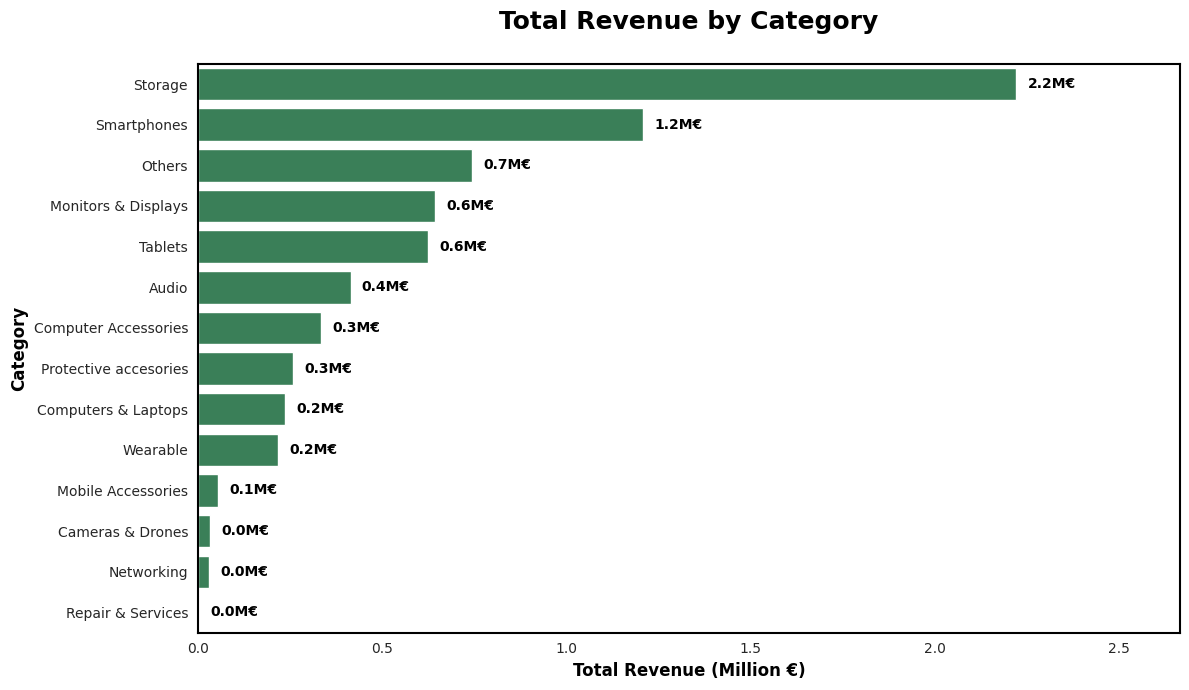

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

# Prepare data -divide by 1,000,000 first!
cat_revenue = orderlines_expanded.groupby('category')['revenue'].sum().sort_values(ascending=False).reset_index()
cat_revenue['revenue_millions'] = cat_revenue['revenue'] / 1_000_000

# Create Plot
plt.figure(figsize=(12, 7))
sns.set_style("white")

# Plot using the scaled column 'revenue_millions'
ax = sns.barplot(
    data=cat_revenue,
    y='category',
    x='revenue_millions',
    color='seagreen'
)
# Stop Matplotlib from using scientific notation (the "1e7" error)
ax.ticklabel_format(style='plain', axis='x')

# Deep Black & Bold Styling
plt.title('Total Revenue by Category', fontsize=18, fontweight='bold', color='black', pad=25)
plt.xlabel('Total Revenue (Million €)', fontsize=12, fontweight='bold', color='black')
plt.ylabel('Category', fontsize=12, fontweight='bold', color='black')

# Bold the tick labels
#plt.xticks(fontweight='bold', color='black')
#plt.yticks(fontweight='bold', color='black')

# Add Labels on the bars
for p in ax.patches:
    width = p.get_width()
    ax.annotate(f'{width:.1f}M€',
                (width, p.get_y() + p.get_height() / 2.),
                ha='left', va='center',
                xytext=(8, 0), # 8 point nudge to the right
                textcoords='offset points',
                fontweight='bold',
                color='black')

#Add space to the right so the text doesn't get cut off
plt.xlim(0, cat_revenue['revenue_millions'].max() * 1.2)

# Darken the spine borders
for spine in ax.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(1.5)

plt.tight_layout()
plt.show()

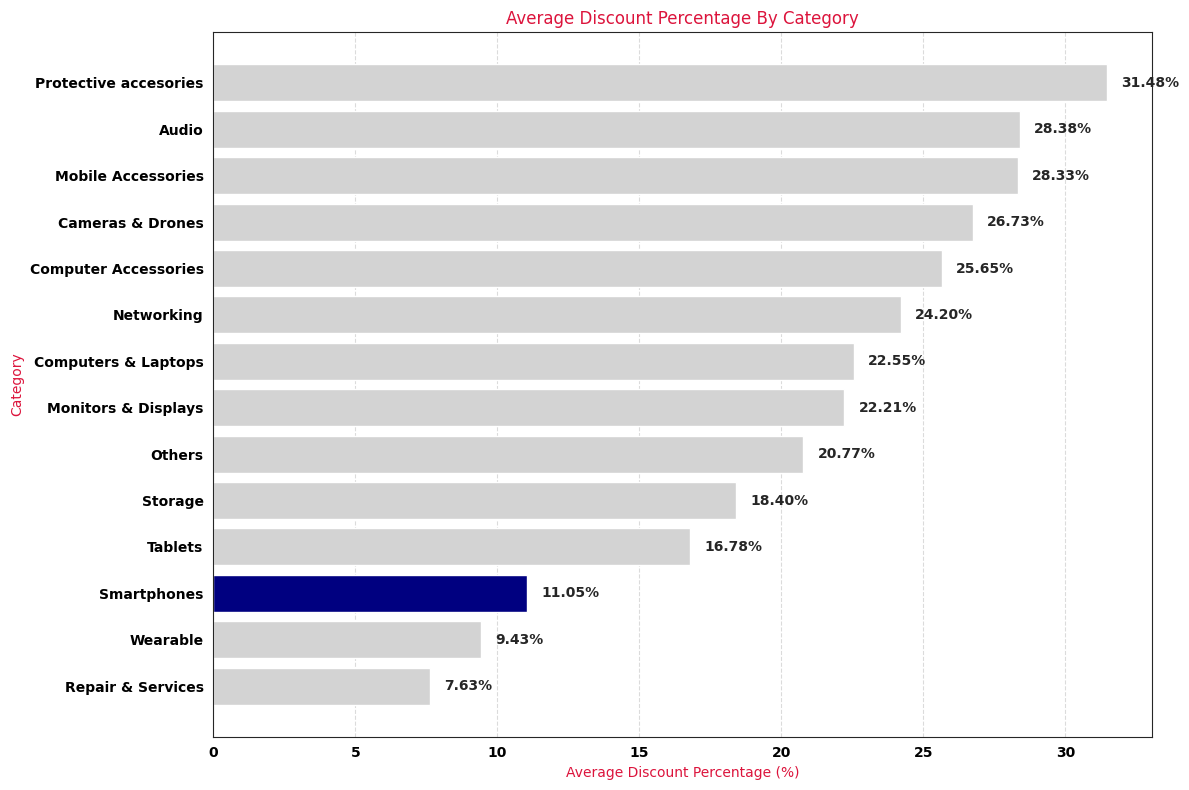

In [53]:
import matplotlib.pyplot as plt

# Calculate the mean percentage discount per category
# sort ascending=True because in a horizontal bar chart (barh),
# the first item starts at the bottom.
category_discount = (orderlines_expanded.groupby('category')['percentage_discount']
                     .mean()
                     .sort_values(ascending=True)
                     .reset_index())
# Create color list
colors = [
    'navy' if cat.lower() == 'smartphones' else 'lightgray'
    for cat in category_discount['category']
]
# Create the horizontal bar chart
plt.figure(figsize=(12, 8))

bars = plt.barh(
    category_discount['category'],
    category_discount['percentage_discount'],
    color=colors
)

# Add labels
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.5,# Position slightly to the right of the bar
        bar.get_y() + bar.get_height()/2,
        f'{width:.2f}%',
        va='center',
        fontweight='bold'
    )
# Bold the tick labels
plt.xticks(fontweight='bold', color='black')
plt.yticks(fontweight='bold', color='black')
# Set labels and title
plt.xlabel('Average Discount Percentage (%)',color='crimson')
plt.ylabel('Category',color='crimson')
plt.title('Average Discount Percentage By Category',color='crimson')
#Clean up layout and display
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('category_discount_plot.png')

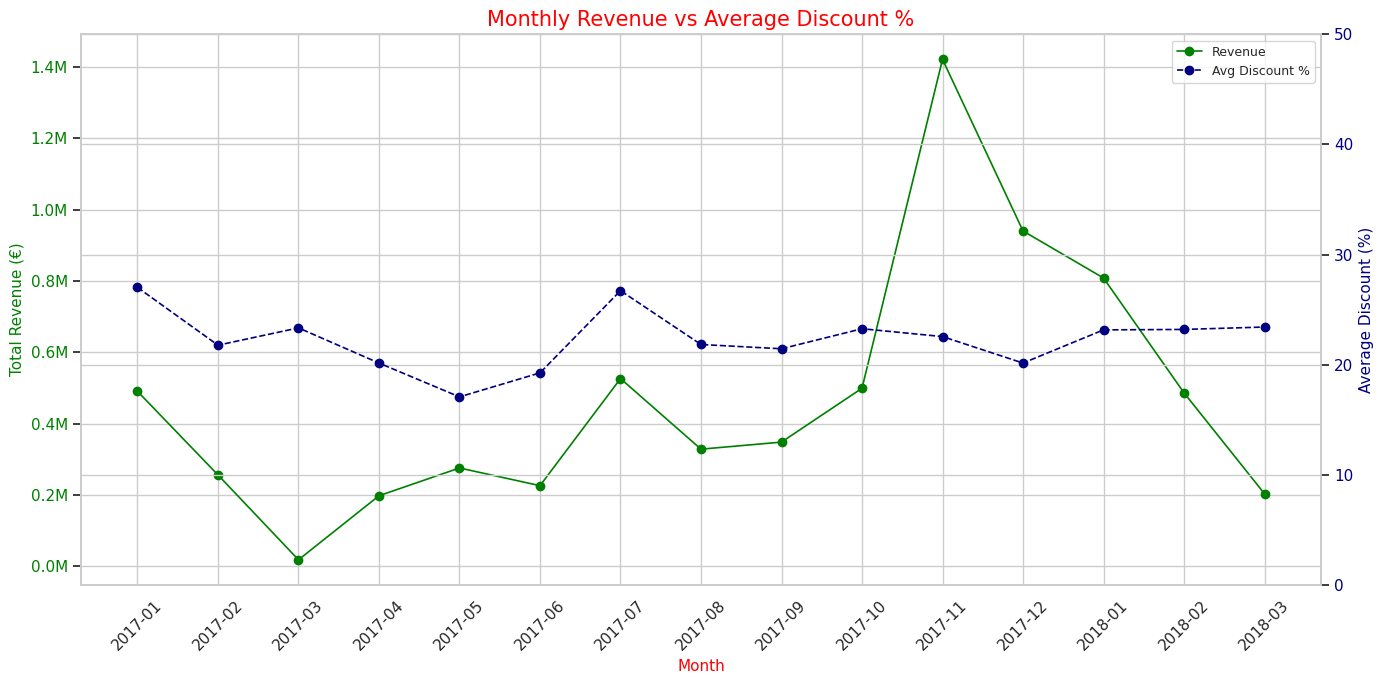

In [54]:
import matplotlib.ticker as ticker
import seaborn as sns
sns.set(style="whitegrid")

# Data Preparation
orderlines_expanded['date'] = pd.to_datetime(orderlines_expanded['date'])
orderlines_expanded['month'] = orderlines_expanded['date'].dt.to_period('M')

monthly = orderlines_expanded.groupby('month').agg({
    'revenue': 'sum',
    'percentage_discount': 'mean'
}).reset_index()

monthly['month'] = monthly['month'].astype(str)

# Plotting
fig, ax1 = plt.subplots(figsize=(14, 7))

# LEFT AXIS (Revenue)
ax1.plot(
    monthly['month'],
    monthly['revenue'],
    marker='o',
    color='green',      # Theme color
    label='Revenue',
    linewidth=1.2
)

# Format Y-axis to Million Euros
ax1.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x/1e6:.1f}M'))#Format the Y-axis values to millions (e.g., 1,200,000 becomes 1.2M)

ax1.set_xlabel('Month', color='red', fontsize=11)
ax1.set_ylabel('Total Revenue (€)', color='green', fontsize=11)
ax1.tick_params(axis='y', labelcolor='green')
ax1.tick_params(axis='x', rotation=45)

# RIGHT AXIS (Discount)
ax2 = ax1.twinx()
ax2.plot(
    monthly['month'],
    monthly['percentage_discount'],
    marker='o',
    linestyle='--',
    color='navy',     # Theme color
    label='Avg Discount %',
    linewidth=1.2
)

ax2.set_ylabel('Average Discount (%)', color='navy', fontsize=11)
ax2.tick_params(axis='y', labelcolor='navy')
ax2.set_ylim(0, 50)

#  Beautification & Legend
plt.title('Monthly Revenue vs Average Discount %', fontsize=15, color='red')

# Combining both legends into one box
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper right', fontsize=9)

plt.tight_layout()
plt.show()

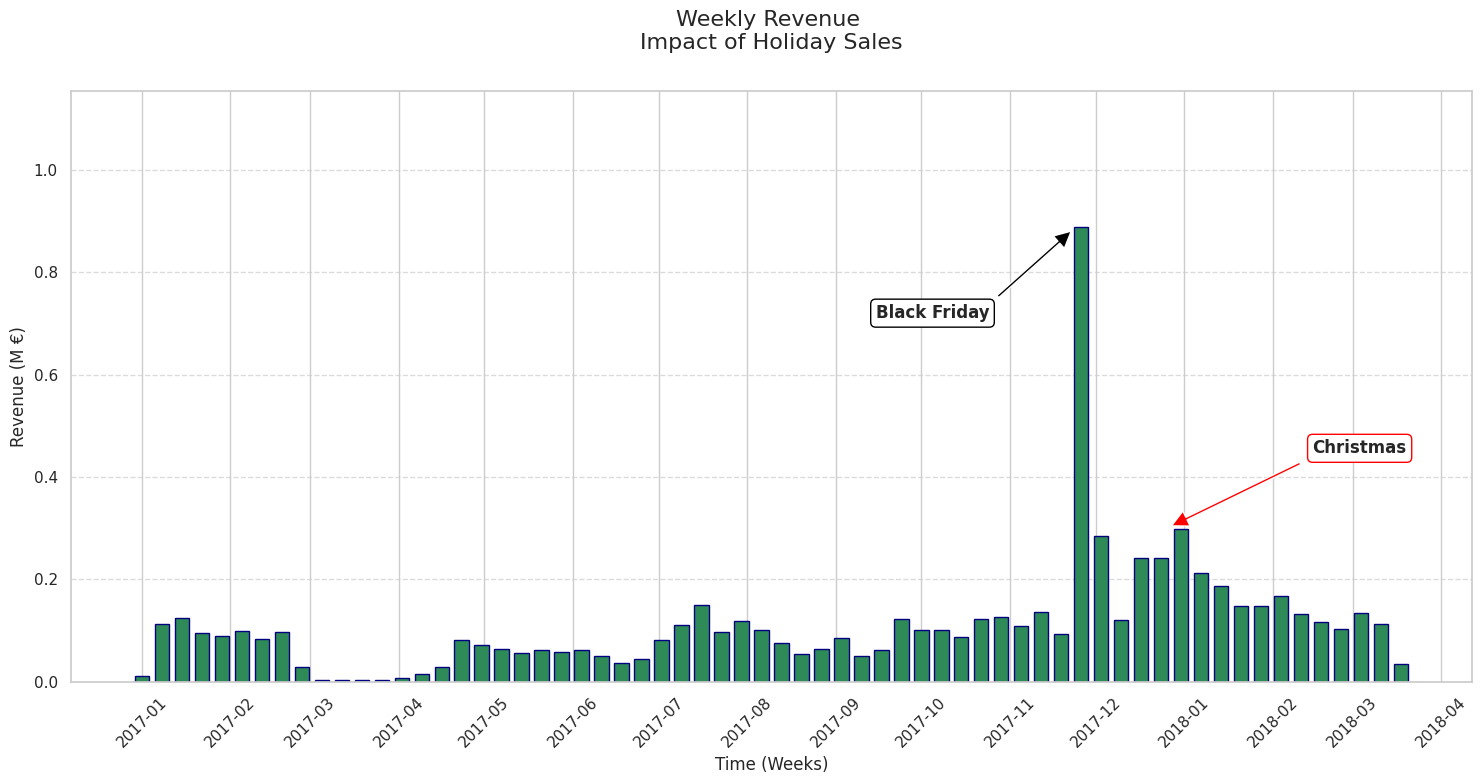

In [55]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Resample revenue by week and convert to millions
weekly_revenue = orderlines_expanded.resample('W', on='date')['revenue'].sum().reset_index()
weekly_revenue['revenue_m'] = weekly_revenue['revenue'] / 1_000_000

#Create the chart
plt.figure(figsize=(15, 8))
plt.bar(weekly_revenue['date'], weekly_revenue['revenue_m'], width=5, color='seagreen', edgecolor='navy')

bf_date = pd.to_datetime('2017-11-24')
# Find the specific revenue point for the BF week
bf_point = weekly_revenue.loc[weekly_revenue['date'] >= bf_date, 'revenue_m'].iloc[0]

# Black Friday Label: Moved to the left and lower to avoid overlap
plt.annotate('Black Friday', xy=(bf_date, bf_point),
             xytext=(pd.to_datetime('2017-09-15'), bf_point * 0.8),
             arrowprops=dict(facecolor='black', shrink=0.05, width=2),
             fontsize=12, fontweight='bold',
             bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black", lw=1))

# Christmas Label
xmas_date = pd.to_datetime('2017-12-25')
xmas_point = weekly_revenue.loc[weekly_revenue['date'] >= xmas_date, 'revenue_m'].iloc[0]
plt.annotate('Christmas', xy=(xmas_date, xmas_point),
             xytext=(pd.to_datetime('2018-02-15'), xmas_point * 1.5),
             arrowprops=dict(facecolor='red', shrink=0.05, width=2),
             fontsize=12, fontweight='bold',
             bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="red", lw=1))

# 4. Formatting Y-axis and Headings
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
plt.xticks(rotation=45)

plt.title('Weekly Revenue \nImpact of Holiday Sales', fontsize=16, pad=30)
plt.xlabel('Time (Weeks)', fontsize=12)
plt.ylabel('Revenue (M €)', fontsize=12)

# Give some extra vertical space at the top for the labels
plt.ylim(0, weekly_revenue['revenue_m'].max() * 1.3)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

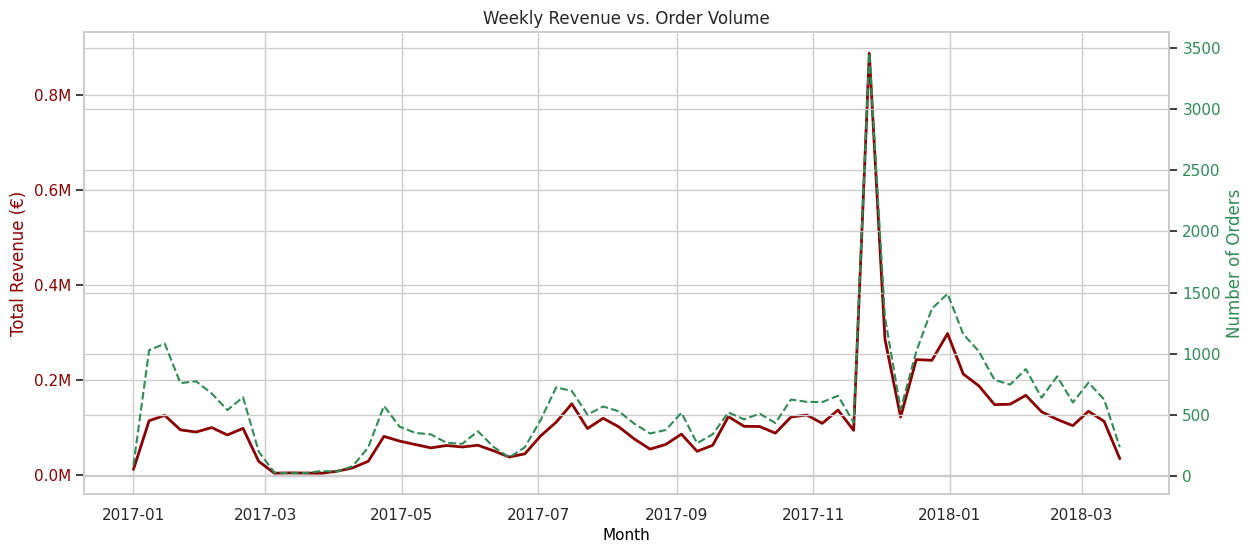

In [56]:
# Revenue vs. Order Volume (Dual Axis)
# Group data by week
weekly_stats = orderlines_expanded.resample('W', on='date').agg({
    'revenue': 'sum',
    'id_order': 'nunique'
}).rename(columns={'id_order': 'order_count'})

# Create dual-axis plot
fig, ax1 = plt.subplots(figsize=(14, 6))
ax1.plot(weekly_stats.index, weekly_stats['revenue'], color='darkred', linewidth=2, label='Revenue')
ax1.set_ylabel('Total Revenue (€)', color='darkred')
ax1.tick_params(axis='y', labelcolor='darkred')
ax1.set_xlabel('Month', color='black', fontsize=11)
ax1.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x/1e6:.1f}M'))
ax2 = ax1.twinx()
ax2.plot(weekly_stats.index, weekly_stats['order_count'], color='seagreen', linestyle='--', label='Order Count')
ax2.set_ylabel('Number of Orders', color='seagreen')
ax2.tick_params(axis='y', labelcolor='seagreen')

plt.title('Weekly Revenue vs. Order Volume')
plt.savefig('revenue_vs_orders_debate.png')

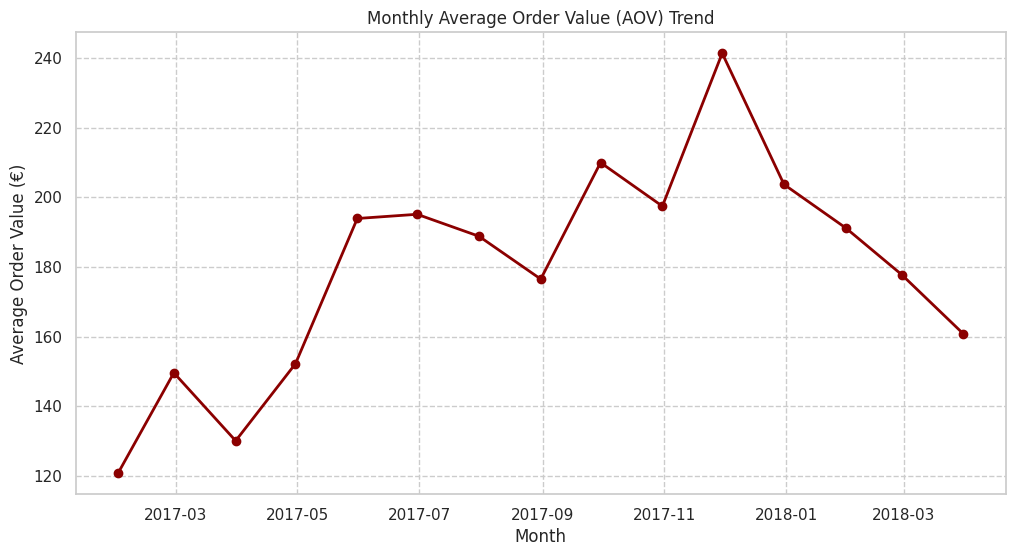

In [57]:
# Calculate Monthly Average Order Value
monthly_aov = orderlines_expanded.resample('ME', on='date').agg({
    'revenue': 'sum',
    'id_order': 'nunique'
})
monthly_aov['AOV'] = monthly_aov['revenue'] / monthly_aov['id_order']

# Plot
plt.figure(figsize=(12, 6))
plt.plot(monthly_aov.index, monthly_aov['AOV'], marker='o', color='darkred', linewidth=2)
plt.title('Monthly Average Order Value (AOV) Trend')
plt.ylabel('Average Order Value (€)')
plt.xlabel('Month')
plt.grid(True, linestyle='--')
plt.savefig('aov_trend.png')

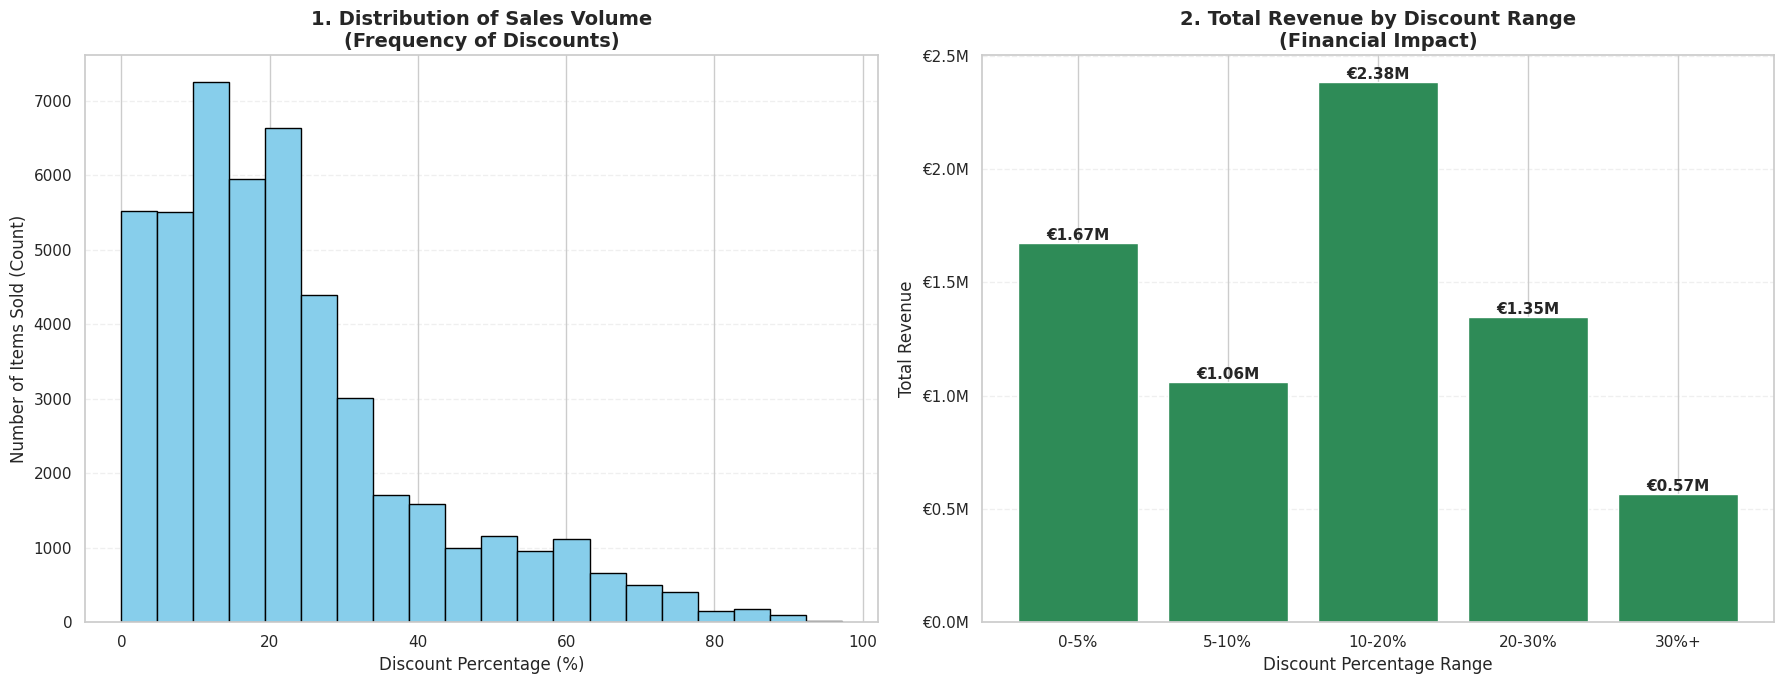

In [58]:
import matplotlib.pyplot as plt
import pandas as pd

# Prepare Bins for the Revenue Bar Chart
bins = [-1, 5, 10, 20, 30, 100]
labels = ['0-5%', '5-10%', '10-20%', '20-30%', '30%+']
orderlines_expanded['discount_bin'] = pd.cut(orderlines_expanded['percentage_discount'],
                                             bins=bins, labels=labels)

# Calculate revenue sum for each bin
discount_revenue = orderlines_expanded.groupby('discount_bin', observed=True)['revenue'].sum().reset_index()

# Create the side-by-side plot
fig, ax = plt.subplots(1, 2, figsize=(18, 7))

# DIAGRAM 1: Volume Histogram
# This shows the frequency of every single discount percentage offered
ax[0].hist(orderlines_expanded['percentage_discount'], bins=20, color='skyblue', edgecolor='black')
ax[0].set_title('1. Distribution of Sales Volume\n(Frequency of Discounts)', fontsize=14, fontweight='bold')
ax[0].set_xlabel('Discount Percentage (%)', fontsize=12)
ax[0].set_ylabel('Number of Items Sold (Count)', fontsize=12)
ax[0].grid(axis='y', linestyle='--', alpha=0.3)

# DIAGRAM 2: Revenue Bar Chart
# This shows the total money earned in the categorized bins you liked
bars = ax[1].bar(discount_revenue['discount_bin'], discount_revenue['revenue'], color='seagreen')
ax[1].set_title('2. Total Revenue by Discount Range\n(Financial Impact)', fontsize=14, fontweight='bold')
ax[1].set_xlabel('Discount Percentage Range', fontsize=12)
ax[1].set_ylabel('Total Revenue', fontsize=12)

# Add Euro values on top of the bars
for bar in bars:
    height = bar.get_height()
    ax[1].text(bar.get_x() + bar.get_width()/2., height,
               f'€{height/1e6:.2f}M',
               ha='center', va='bottom', fontweight='bold', fontsize=11)

# Format the Y-axis to show Millions clearly
ax[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'€{x/1e6:.1f}M'))
ax[1].grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig('volume_hist_revenue_bar.png')